In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import xgboost as xgb


In [93]:
X_train = pd.read_csv('data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('data/y_train.csv',index_col='ROW_ID')
sample_submission = pd.read_csv('data/sample_submission.csv',index_col='ROW_ID')

# Features

In [94]:
RET_features = [f'RET_{i}' for i in range(1,20)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,20)]
TURNOVER_features = ['AVG_DAILY_TURNOVER']

In [95]:
for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i+1]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i+1]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

In [96]:
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]

EMA

In [97]:
ret_cols = [f"RET_{i}" for i in range(1, 21)]
r = X_train[ret_cols].to_numpy()

rtest = X_test[ret_cols].to_numpy()

def ema(arr, L):
    alpha = 2/(L+1)
    w = (1-alpha) ** np.arange(L)  # 0..L-1
    w = w / w.sum()
    return (arr[:, :L] * w).sum(axis=1)

X_train["ema3"]  = ema(r, 3)
X_train["ema5"]  = ema(r, 5)
X_train["ema10"] = ema(r,10)


X_test["ema3"]  = ema(rtest, 3)
X_test["ema5"]  = ema(rtest, 5)
X_test["ema10"] = ema(rtest,10)

m20 = r.mean(axis=1)
s20 = r.std(axis=1, ddof=0)

m20test = rtest.mean(axis=1)
s20test = rtest.std(axis=1, ddof=0)

X_train["z20"] = m20 / (s20 + 1e-12)
X_test["z20"] = m20test / (s20test + 1e-12)

Streak de signe et entropie 

In [98]:
sign = np.sign(r)  
signtest = np.sign(rtest)

def last_streak_len(sig_row, positive=True):
    # part de RET_1 vers RET_20
    target = 1 if positive else -1
    cnt = 0
    for v in sig_row[:20]:  # [:20] explicite
        if v == target:
            cnt += 1
        else:
            break
    return cnt

X_train["streak_pos"] = [last_streak_len(s, True) for s in sign]
X_train["streak_neg"] = [last_streak_len(s, False) for s in sign]

X_test["streak_pos"] = [last_streak_len(s, True) for s in signtest]
X_test["streak_neg"] = [last_streak_len(s, False) for s in signtest]

p = (r > 0).mean(axis=1)
p = np.clip(p, 1e-9, 1 - 1e-9)
X_train["sign_entropy20"] = -(p*np.log(p) + (1-p)*np.log(1-p))

ptest = (rtest > 0).mean(axis=1)    
ptest = np.clip(ptest, 1e-9, 1 - 1e-9)
X_test["sign_entropy20"] = -(ptest*np.log(ptest) + (1-ptest)*np.log(1-ptest))


Qualité de rendement (Sharpe10, Sortino10, t-stat(mean10))

In [99]:
r10 = r[:, :10]
m10 = r10.mean(axis=1)
s10 = r10.std(axis=1, ddof=0)
neg10 = np.minimum(r10, 0)

r10test = rtest[:, :10]
m10test = r10test.mean(axis=1)
s10test = r10test.std(axis=1, ddof=0)
neg10test = np.minimum(r10test, 0)

X_train["sharpe10"]   = m10 / (s10 + 1e-12)
downside10 = np.sqrt((neg10**2).mean(axis=1))
X_train["sortino10"]  = m10 / (downside10 + 1e-12)
X_train["tstat_mean10"] = m10 / (s10/np.sqrt(10) + 1e-12)

X_test["sharpe10"]   = m10test / (s10test + 1e-12)
downside10test = np.sqrt((neg10test**2).mean(axis=1))
X_test["sortino10"]  = m10test / (downside10test + 1e-12)
X_test["tstat_mean10"] = m10test / (s10test/np.sqrt(10) + 1e-12)


In [100]:
X_train["vol10"]         = s10
X_train["downside_dev10"]= downside10

X_test["vol10"]         = s10test
X_test["downside_dev10"]= downside10test

def maxdd_and_recovery(row):
    c = np.cumsum(row)                   # equity curve 20j
    peak = np.maximum.accumulate(c)
    dd = (c - peak)
    maxdd = dd.min()                     # drawdown (négatif)
    # recovery: jours depuis le dernier pic
    last_peak_idx = np.where(c == peak)[0][-1]
    recovery = 20 - 1 - last_peak_idx
    return maxdd, recovery

md_rec = np.apply_along_axis(maxdd_and_recovery, 1, r)
X_train["maxdd20"]   = md_rec[:,0]
X_train["recovery20"]= md_rec[:,1]

md_rec_test = np.apply_along_axis(maxdd_and_recovery, 1, rtest)
X_test["maxdd20"]    = md_rec_test[:,0]
X_test["recovery20"] = md_rec_test[:,1]


Liquidity / turnover (moyenne/écart-type volumes, autocorr, corr ret–liq ; turnover moyen)

In [101]:

ret_cols = [f"RET_{i}" for i in range(1, 21)]
vol_cols = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]
EPS = 1e-12

def add_volume_features(X):
    v = np.nan_to_num(X[vol_cols].to_numpy(), nan=0.0)
    r = np.nan_to_num(X[ret_cols].to_numpy(), nan=0.0)

    X["sv_mean20"] = v.mean(axis=1)
    X["sv_std20"]  = v.std(axis=1, ddof=0)

    v_mean = v.mean(axis=1, keepdims=True)
    vx = v - v_mean
    num = (vx[:,1:] * vx[:,:-1]).sum(axis=1)
    den = np.sqrt((vx[:,1:]**2).sum(axis=1) * (vx[:,:-1]**2).sum(axis=1))
    X["sv_autocorr1"] = num / (den + EPS)

    rx = r - r.mean(axis=1, keepdims=True)
    num = (rx * vx).sum(axis=1)
    den = np.sqrt((rx**2).sum(axis=1) * (vx**2).sum(axis=1))
    X["corr_ret_sv20"] = num / (den + EPS)

    X["avg_turnover"] = X["AVG_DAILY_TURNOVER"]
    return X

X_train = add_volume_features(X_train.copy())
X_test  = add_volume_features(X_test.copy())


In [117]:
2773 * 65

180245

In [103]:
features = [col for col in X_train.columns if col not in ['TS', 'ALLOCATION']]

In [74]:
len(features)

70

MODEL

In [50]:

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

train_dates = X_train['TS'].unique()
scores = []
models = []
best_rounds = []
best_scores = []

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

for i, (idx_tr_dates, idx_val_dates) in enumerate(kf.split(train_dates), 1):
    tr_dates = train_dates[idx_tr_dates]
    val_dates = train_dates[idx_val_dates]

    m_tr = X_train['TS'].isin(tr_dates)
    m_val = X_train['TS'].isin(val_dates)

    x_tr = X_train.loc[m_tr, features]
    y_tr = y_train_binary.loc[m_tr]
    x_val = X_train.loc[m_val, features]
    y_val = y_train_binary.loc[m_val]

    # sw = None
    # sw = w_tr.loc[m_tr]
   

    clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=100,
        n_jobs=-1
    )

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    clf.fit(**fit_kwargs)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    models.append(clf)
    scores.append(acc)
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


Fold 01 - Acc: 52.37% | best_iter=26 | best_logloss=0.6915805420198688
Fold 02 - Acc: 52.83% | best_iter=37 | best_logloss=0.6907791381078197
Fold 03 - Acc: 51.40% | best_iter=13 | best_logloss=0.6924676835635913
Fold 04 - Acc: 51.41% | best_iter=25 | best_logloss=0.6926373366364768
Fold 05 - Acc: 52.86% | best_iter=41 | best_logloss=0.6908203877299668
Fold 06 - Acc: 51.34% | best_iter=28 | best_logloss=0.6925526350777998
Fold 07 - Acc: 51.97% | best_iter=32 | best_logloss=0.6917911848122131
Fold 08 - Acc: 52.09% | best_iter=82 | best_logloss=0.6918979601077456
Fold 09 - Acc: 52.03% | best_iter=46 | best_logloss=0.6917738275953678
Fold 10 - Acc: 53.79% | best_iter=32 | best_logloss=0.6905766079555581
Accuracy: 52.21% [51.47 ; 52.95] (±0.74)


In [114]:

train_dates = X_train['TS'].unique()
sample_train_dates = np.random.choice(train_dates, size=int(len(train_dates) * 0.9), replace=False)
sample_val_dates = np.array([date for date in train_dates if date not in sample_train_dates])
m_tr = X_train['TS'].isin(sample_train_dates)
m_val = X_train['TS'].isin(sample_val_dates)

x_tr, x_val, y_tr, y_val = X_train.loc[m_tr, features], X_train.loc[m_val, features], y_train_binary.loc[m_tr], y_train_binary.loc[m_val] 

clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=10,
        n_jobs=-1
    )

clf.fit(X=x_tr, y=y_tr, eval_set=[(x_val, y_val)], verbose=False)


p_val = clf.predict_proba(x_val)[:, 1]
acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

print(f"Accuracy: {acc*100:.2f}%")

Y_pred_xgb = clf.predict_proba(X_test[features])[:, 1]

Y_pred_xgb = pd.DataFrame(Y_pred_xgb, columns=["prediction"], index=X_test.index)
Y_pred_xgb["prediction"] = (Y_pred_xgb["prediction"] >= 0.5).astype(int)
Y_pred_xgb.to_csv("data/xgb_v3.csv")


Accuracy: 53.37%


<Axes: >

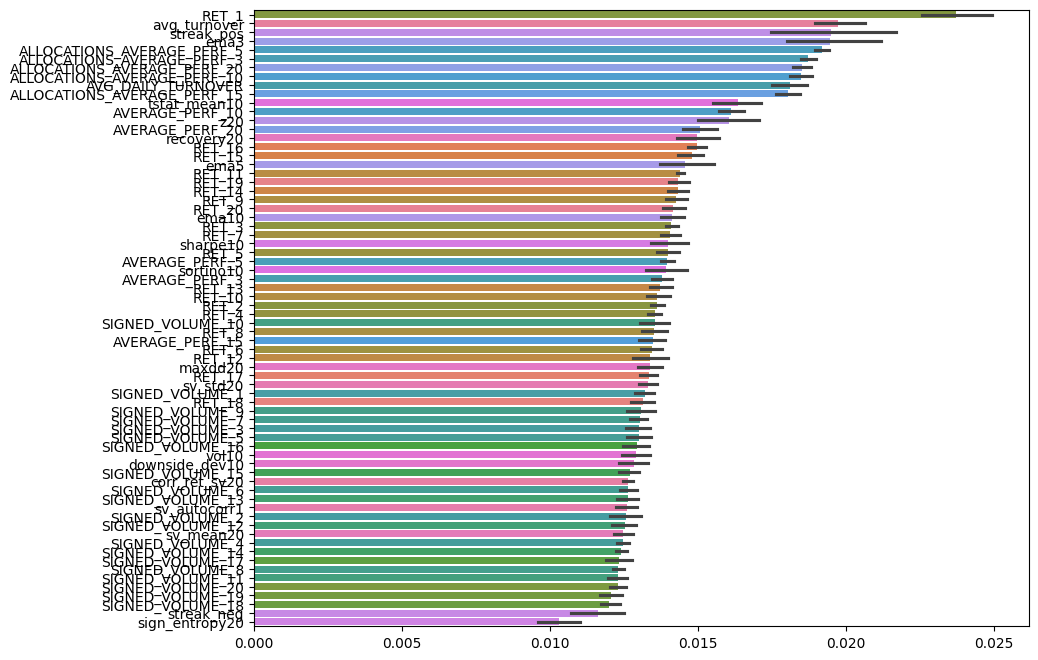

In [48]:
feature_importances = pd.DataFrame([model.feature_importances_ for model in models], columns=features)
plt.figure(figsize=(10, 8))

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)



## With linear model

In [72]:

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

train_dates = X_train['TS'].unique()
scores = []
models = []
best_rounds = []
best_scores = []

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

for i, (idx_tr_dates, idx_val_dates) in enumerate(kf.split(train_dates), 1):
    tr_dates = train_dates[idx_tr_dates]
    val_dates = train_dates[idx_val_dates]

    m_tr = X_train['TS'].isin(tr_dates)
    m_val = X_train['TS'].isin(val_dates)

    x_tr = X_train.loc[m_tr, features]
    y_tr = y_train_binary.loc[m_tr]
    x_val = X_train.loc[m_val, features]
    y_val = y_train_binary.loc[m_val]

    # sw = None
    # sw = w_tr.loc[m_tr]
   

    clf = xgb.XGBClassifier(
    booster="gblinear",
    objective="binary:logistic",
    eval_metric="logloss",

    # régularisation (à tuner)
    reg_lambda=10.0,     # L2 (type Ridge) 5–100 à tester
    reg_alpha=0.2,       # >0 pour Elastic Net (ex. 0.1–1.0)

    # itérations / pas
    n_estimators=2000,   # nb d’updates linéaires
    learning_rate=0.1,   # 0.05–0.5 à tester

    random_state=42,
    early_stopping_rounds=100,
    n_jobs=-1
)

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    clf.fit(**fit_kwargs)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    models.append(clf)
    scores.append(acc)
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


Fold 01 - Acc: 51.37% | best_iter=0 | best_logloss=0.6930670734954659
Fold 02 - Acc: 50.14% | best_iter=0 | best_logloss=0.6931459249484321
Fold 03 - Acc: 50.02% | best_iter=143 | best_logloss=0.6931614908185134
Fold 04 - Acc: 49.56% | best_iter=150 | best_logloss=0.6932371905100938
Fold 05 - Acc: 50.53% | best_iter=123 | best_logloss=0.6931077950995884
Fold 06 - Acc: 49.22% | best_iter=0 | best_logloss=0.6933045294045806
Fold 07 - Acc: 51.06% | best_iter=0 | best_logloss=0.6930734879604414
Fold 08 - Acc: 49.52% | best_iter=0 | best_logloss=0.6932409473109067
Fold 09 - Acc: 51.32% | best_iter=0 | best_logloss=0.6930670679294212
Fold 10 - Acc: 49.99% | best_iter=104 | best_logloss=0.693166127293615
Accuracy: 50.27% [49.54 ; 51.00] (±0.73)


# Alloc embedding with clustering

## With alloc embedding with SVD

In [57]:

class AllocationSVDEmbedder:
    def __init__(self, k=5, ts_col="TS", alloc_col="ALLOCATION", value_col="pivot_cs"):
        self.k, self.ts_col, self.alloc_col, self.value_col = k, ts_col, alloc_col, value_col
        self.alloc_order_ = None
        self.embeddings_ = None
        self.zero_ = None

    def _make_matrix(self, df):
        M = df.pivot(index=self.ts_col, columns=self.alloc_col, values=self.value_col)
        M = M.sort_index(axis=0).sort_index(axis=1)
        # centrage par TS pour enlever le mode commun du jour
        M = M.sub(M.mean(axis=1), axis=0).fillna(0.0)
        # standardisation par allocation (col)
        col_std = M.std(axis=0, ddof=0).replace(0, 1.0)
        M = M / col_std
        return M

    def fit(self, df_train: pd.DataFrame):
        M = self._make_matrix(df_train)
        U, S, Vt = np.linalg.svd(M.to_numpy(), full_matrices=False)
        Vtk = Vt[:self.k, :]                    # (k, n_alloc)
        Sk = S[:self.k]                         # (k,)
        E = (Vtk.T * Sk)                        # (n_alloc, k) -> alloc coords = V Σ
        self.alloc_order_ = M.columns.to_list()
        self.embeddings_ = pd.DataFrame(E, index=self.alloc_order_,
                                        columns=[f"alloc_svd_{i+1}" for i in range(self.k)])
        self.zero_ = np.zeros(self.k, dtype=float)
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        if self.embeddings_ is None:
            raise RuntimeError("Call fit() first.")
        emb = self.embeddings_
        vals = df[self.alloc_col].map(lambda a: emb.loc[a].to_numpy() if a in emb.index else self.zero_)
        X = np.vstack(vals.to_list())
        for i in range(self.k):
            df[f"alloc_svd_{i+1}"] = X[:, i]
        return df

    def fit_transform(self, df_train: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df_train).transform(df_train.copy())


In [ ]:
if "pivot_cs" not in X_train.columns:
    # ex: moyenne des 10 derniers retours; remplace par z20/sharpe10 si déjà calculé
    ret_cols_10 = [f"RET_{i}" for i in range(1, 11)]
    X_train["pivot_cs"] = X_train[ret_cols_10].mean(axis=1)

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

train_dates = X_train['TS'].unique()
scores, models, best_rounds, best_scores = [], [], [], []
embedders = []  # (optionnel) pour réutiliser sur test ensuite

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

for i, (idx_tr_dates, idx_val_dates) in enumerate(kf.split(train_dates), 1):
    tr_dates = train_dates[idx_tr_dates]
    val_dates = train_dates[idx_val_dates]

    m_tr = X_train['TS'].isin(tr_dates)
    m_val = X_train['TS'].isin(val_dates)

    # --- SVD embedding (fit sur TRAIN du fold uniquement) ---
    embedder = AllocationSVDEmbedder(
        k=5, ts_col="TS", alloc_col="ALLOCATION", value_col="pivot_cs"
    )
    df_fit = X_train.loc[m_tr, ["TS", "ALLOCATION", "pivot_cs"]]
    embedder.fit(df_fit)

    # on transforme des DF ne contenant que TS/ALLOCATION pour récupérer alloc_svd_*
    df_tr_ids  = X_train.loc[m_tr, ["TS", "ALLOCATION"]].copy()
    df_val_ids = X_train.loc[m_val, ["TS", "ALLOCATION"]].copy()
    df_tr_emb  = embedder.transform(df_tr_ids)
    df_val_emb = embedder.transform(df_val_ids)
    emb_cols = [c for c in df_tr_emb.columns if c.startswith("alloc_svd_")]

    # --- Features finales du fold = features existantes + embeddings ---
    x_tr_base = X_train.loc[m_tr, features].reset_index(drop=True)
    x_val_base = X_train.loc[m_val, features].reset_index(drop=True)
    x_tr = pd.concat([x_tr_base, df_tr_emb[emb_cols].reset_index(drop=True)], axis=1)
    x_val = pd.concat([x_val_base, df_val_emb[emb_cols].reset_index(drop=True)], axis=1)

    y_tr = y_train_binary.loc[m_tr].reset_index(drop=True)
    y_val = y_train_binary.loc[m_val].reset_index(drop=True)

    # --- Modèle ---
    clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=100,
        n_jobs=-1
    )

    clf.fit(X=x_tr, y=y_tr, eval_set=[(x_val, y_val)], verbose=False)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    models.append(clf)
    embedders.append(embedder)  # (optionnel) pour servir le set test plus tard
    scores.append(acc)
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")

Fold 01 - Acc: 53.14% | best_iter=89 | best_logloss=0.690110158834526
Fold 02 - Acc: 53.16% | best_iter=56 | best_logloss=0.6901046501102537
Fold 03 - Acc: 52.27% | best_iter=16 | best_logloss=0.6917868491820888
Fold 04 - Acc: 51.81% | best_iter=41 | best_logloss=0.6917991595859496
Fold 05 - Acc: 53.68% | best_iter=38 | best_logloss=0.6898246346050354
Fold 06 - Acc: 51.32% | best_iter=10 | best_logloss=0.6926667100321879
Fold 07 - Acc: 52.86% | best_iter=39 | best_logloss=0.6906095113101451
Fold 08 - Acc: 52.51% | best_iter=44 | best_logloss=0.6914131644516315
Fold 09 - Acc: 52.47% | best_iter=46 | best_logloss=0.6906331044539781
Fold 10 - Acc: 53.26% | best_iter=42 | best_logloss=0.6908456333774026
Accuracy: 52.65% [51.97 ; 53.33] (±0.68)


In [60]:

y_train_binary = (y_train["target"] > 0).astype(int)

if "pivot_cs" not in X_train.columns:
    ret_cols_10 = [f"RET_{i}" for i in range(1, 11)]
    X_train["pivot_cs"] = X_train[ret_cols_10].mean(axis=1)

embedder = AllocationSVDEmbedder(k=5, ts_col="TS", alloc_col="ALLOCATION", value_col="pivot_cs")
embedder.fit(X_train[["TS", "ALLOCATION", "pivot_cs"]])

tr_ids  = X_train[["TS", "ALLOCATION"]].copy()
te_ids  = X_test[["TS", "ALLOCATION"]].copy()
tr_emb  = embedder.transform(tr_ids)
te_emb  = embedder.transform(te_ids)
emb_cols = [c for c in tr_emb.columns if c.startswith("alloc_svd_")]

# 4) Matrices finales
Xtr = pd.concat([X_train[features].reset_index(drop=True), tr_emb[emb_cols].reset_index(drop=True)], axis=1)
Xte = pd.concat([X_test[features].reset_index(drop=True),  te_emb[emb_cols].reset_index(drop=True)], axis=1)
ytr = y_train_binary.reset_index(drop=True)


n_best = int(np.nanmedian(best_rounds))     
clf_final = xgb.XGBClassifier(
    n_estimators=n_best,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)
clf_final.fit(Xtr, ytr)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [68]:
proba_test = clf_final.predict_proba(Xte)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

Y_pred = pd.DataFrame({
    "prediction": pred_test
})

Y_pred.index = X_test.index



In [69]:
Y_pred

,prediction
ROW_ID,
180245,1
180246,0
180247,1
180248,0
180249,0
...,...
187975,1
187976,1
187977,1


In [71]:
Y_pred.to_csv("data/xgb_v2_SVD.csv")